# Fig. 6 & 7: CCDF of Regime Persistence Times and Transition Durations

This notebook computes and plots:
- **Figure 6**: Complementary cumulative distribution functions (CCDFs) of state persistence
  times τ_AB (persistence in A before reaching B) and τ_BA (persistence in B before reaching A)
  with bootstrap 95% confidence intervals.
- **Figure 7**: Distribution of transition durations between vortex regimes (histograms + KDE).

The transition-duration density (Fig. 7) uses a **regularized log-transform KDE**, $P(t)=Q(\log(t+c))/(t+c)$ with $Q$ a Gaussian KDE, which keeps the density finite and non-negative at short durations.

Real  | tau_AB: 610, tau_BA: 610
Pred  | tau_AB: 227, tau_BA: 226


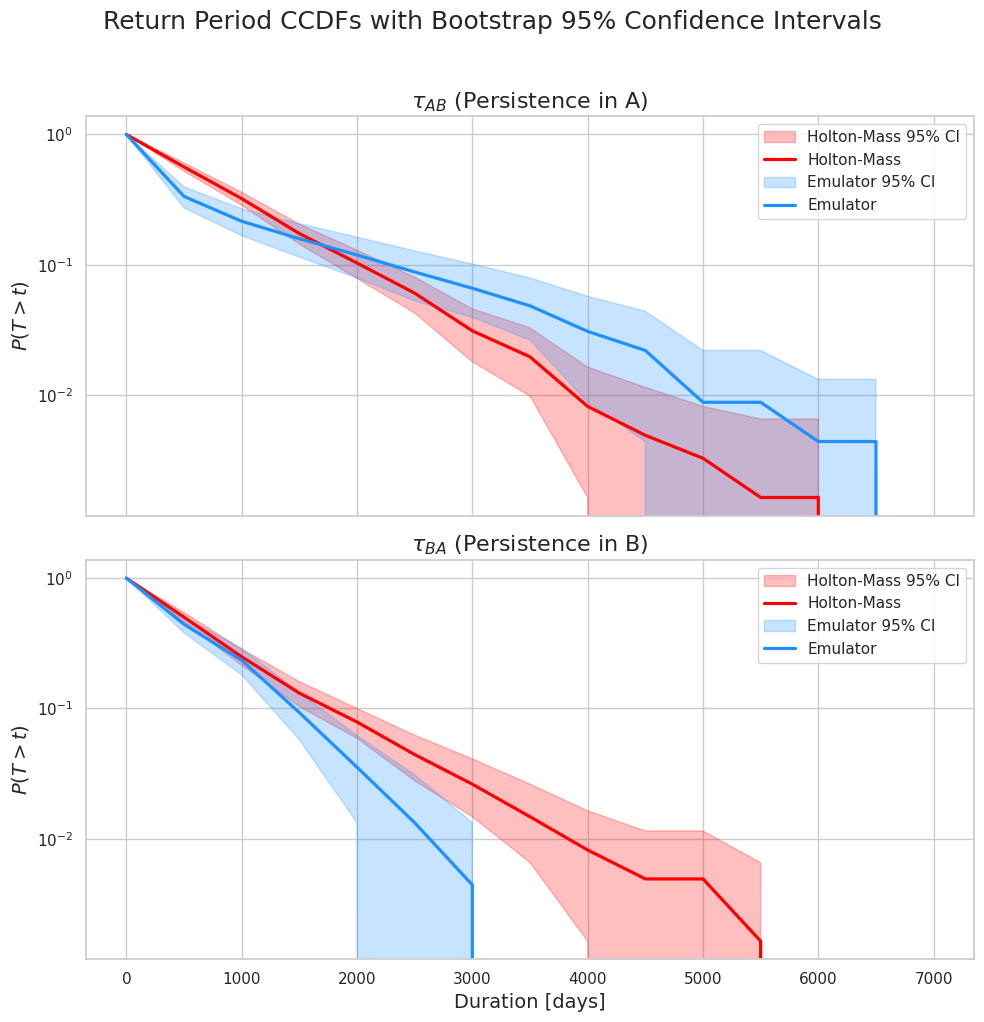

Transition durations | Real: 1220, Pred: 453


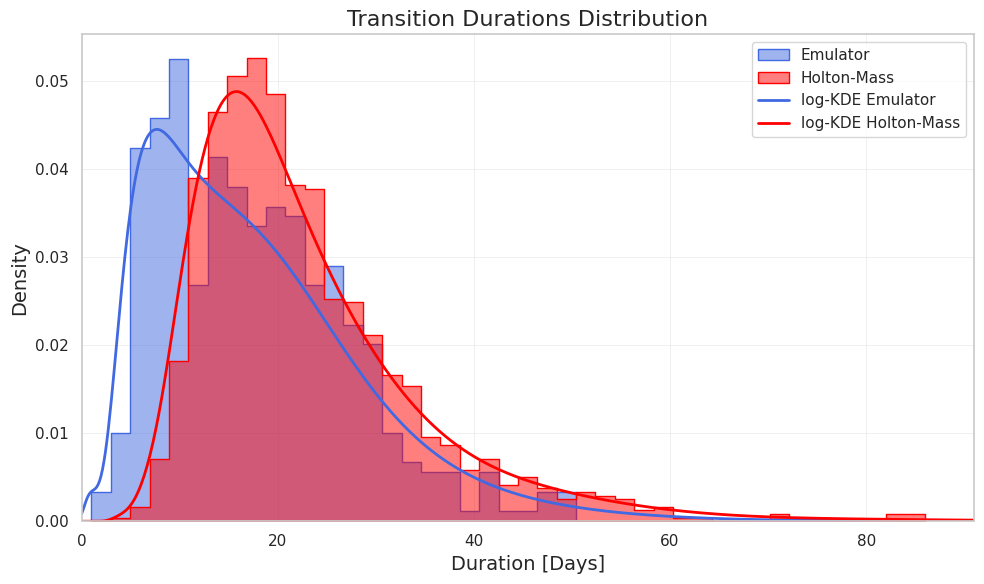

Done.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import gaussian_kde

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

# ============================================================
# PATHS — update these to match your environment
# ============================================================
DATA_HM_PATH = r"/home/danyul/ssw/stochastic_trajectories.npy"
DATA_PRED_PATH = r"/home/danyul/ssw/predictions.npy"
OUT_DIR = "../graphs_for_paper"   # bundle output folder for paper PNGs
os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# Parameters
# ============================================================
time_step = 1_000_000
level = 63                        # index for U(30 km)
upper_bound = 53.8 / 2.8935      # u_A threshold (normalized)
lower_bound = 7.41                # u_B threshold (normalized)


# ============================================================
# Helper functions
# ============================================================
def calculate_return_periods_separate(y, u, l):
    """
    Calculate return periods separately for A->B and B->A transitions.

    Returns
    -------
    tau_AB : list of persistence times in state A before reaching B
    tau_BA : list of persistence times in state B before reaching A
    """
    tau_AB, tau_BA = [], []
    s = None
    above_u = False
    below_l = False
    for i in range(1, len(y)):
        if y[i] < l:
            if above_u and s is not None:
                tau_AB.append(i - s)
                s = None
            below_l = True
            above_u = False
        elif y[i] > u:
            if below_l and s is not None:
                tau_BA.append(i - s)
                s = None
            above_u = True
            below_l = False
        if below_l and s is None:
            s = i
        if above_u and s is None:
            s = i
    return tau_AB, tau_BA


def calculate_transition_durations(u_series, upper, lower):
    """
    Calculate durations of completed transitions (time spent in intermediate zone).
    Tracks both A->B and B->A transitions; cancels if the system returns
    to the origin regime before completing the transition.
    """
    u_series = np.asarray(u_series).ravel()
    if u_series.size == 0:
        return []
    upper, lower = float(upper), float(lower)

    def zone(x):
        if np.isnan(x):
            return "nan"
        if x > upper:
            return "above"
        if x < lower:
            return "below"
        return "between"

    durations = []
    state = "idle"
    start_idx = None
    prev_z = zone(u_series[0])

    for i in range(1, len(u_series)):
        z = zone(u_series[i])
        if z == "nan":
            state, start_idx = "idle", None
            prev_z = z
            continue

        if state == "idle":
            if prev_z == "above" and z != "above":
                state, start_idx = "A_to_b", i
                if z == "below":
                    durations.append(0)
                    state, start_idx = "idle", None
            elif prev_z == "below" and z != "below":
                state, start_idx = "b_to_A", i
                if z == "above":
                    durations.append(0)
                    state, start_idx = "idle", None
        elif state == "A_to_b":
            if z == "above":
                state, start_idx = "idle", None
            elif z == "below":
                durations.append(i - start_idx)
                state, start_idx = "idle", None
        elif state == "b_to_A":
            if z == "below":
                state, start_idx = "idle", None
            elif z == "above":
                durations.append(i - start_idx)
                state, start_idx = "idle", None
        prev_z = z

    return durations


def empirical_ccdf(sorted_sample, bins):
    """Compute empirical CCDF P(T > t) evaluated at fixed bin edges."""
    n = len(sorted_sample)
    idx = np.searchsorted(sorted_sample, bins, side="right")
    return 1.0 - idx / n


def bootstrap_ccdf(durations, bins, n_bootstrap=1000, seed=42):
    """Compute bootstrap CCDF with percentile confidence bands."""
    durations = np.asarray(durations)
    n = len(durations)
    sorted_original = np.sort(durations)
    rng = np.random.default_rng(seed)
    boot = np.empty((n_bootstrap, len(bins)))
    for b in range(n_bootstrap):
        sample = rng.choice(sorted_original, size=n, replace=True)
        boot[b, :] = empirical_ccdf(np.sort(sample), bins)
    low = np.percentile(boot, 2.5, axis=0)
    med = np.percentile(boot, 50.0, axis=0)
    high = np.percentile(boot, 97.5, axis=0)
    return med, low, high


def shared_bin_edges(a, b, bins=20, method=None, data_range=None):
    """Compute shared histogram bin edges from pooled data."""
    a, b = np.asarray(a), np.asarray(b)
    data = np.concatenate([a, b])
    if data_range is None:
        dmin, dmax = np.nanmin(data), np.nanmax(data)
        if dmin == dmax:
            eps = 1e-9 if dmin == 0 else 1e-9 * abs(dmin)
            data_range = (dmin - eps, dmax + eps)
    if isinstance(bins, (list, tuple, np.ndarray)):
        return np.asarray(bins, dtype=float)
    rule = method if method is not None else bins
    return np.histogram_bin_edges(data, bins=rule, range=data_range)


# Regularized log-transform KDE for the transition-duration density.
# A linear-space Gaussian KDE leaks probability to negative (unphysical) durations;
# the plain s = log(t) transform instead leaves a spurious spike at t = 0 from the
# 1/t Jacobian. We fit a Gaussian KDE Q(s) on s = log(t + c) and map back via
#     P(t) = Q(log(t + c)) / (t + c).
# The offset c sits INSIDE the log so the Jacobian stays finite near t = 0 (killing
# the spike); BW_SCALE widens the kernel to smooth the residual bump. Note that
# c + log(t) (offset outside the log) is a pure shift and would leave P(t) unchanged.
REG_C = 2.0       # regularization offset
BW_SCALE = 1.5    # Gaussian-kernel bandwidth multiplier (>1 = wider/smoother)


def log_kde(durations, grid, c=REG_C, bw_scale=BW_SCALE):
    d = np.asarray(durations, dtype=float)
    Q = gaussian_kde(np.log(d + c))           # all durations usable since t + c > 0
    Q.set_bandwidth(Q.factor * bw_scale)      # wider kernel
    return Q(np.log(grid + c)) / (grid + c)


# ============================================================
# Load data
# ============================================================
real_data = np.load(DATA_HM_PATH)
preds = np.load(DATA_PRED_PATH)

real_data_1d = real_data[:time_step, 1, level]
predictions_1d = preds[:time_step, level]

# ============================================================
# Compute separate return periods (persistence times)
# ============================================================
real_tau_AB, real_tau_BA = calculate_return_periods_separate(real_data_1d, upper_bound, lower_bound)
pred_tau_AB, pred_tau_BA = calculate_return_periods_separate(predictions_1d, upper_bound, lower_bound)

print(f"Real  | tau_AB: {len(real_tau_AB)}, tau_BA: {len(real_tau_BA)}")
print(f"Pred  | tau_AB: {len(pred_tau_AB)}, tau_BA: {len(pred_tau_BA)}")

# ============================================================
# FIGURE 6: CCDF with Bootstrap 95% Confidence Intervals
# ============================================================
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

# Synchronized x-axis bins (500-day spacing)
global_max = max(
    np.max(real_tau_AB), np.max(pred_tau_AB),
    np.max(real_tau_BA), np.max(pred_tau_BA),
)
bins = np.arange(0, global_max + 500, 500)

for ax, real_dur, pred_dur, label in [
    (axes[0], real_tau_AB, pred_tau_AB, r"$\tau_{AB}$ (Persistence in A)"),
    (axes[1], real_tau_BA, pred_tau_BA, r"$\tau_{BA}$ (Persistence in B)"),
]:
    hm_med, hm_low, hm_high = bootstrap_ccdf(real_dur, bins, n_bootstrap=1000, seed=123)
    em_med, em_low, em_high = bootstrap_ccdf(pred_dur, bins, n_bootstrap=1000, seed=456)

    # Holton-Mass = RED
    ax.fill_between(bins, hm_low, hm_high, color="red", alpha=0.25, label="Holton-Mass 95% CI")
    ax.plot(bins, hm_med, color="red", linewidth=2.3, label="Holton-Mass")

    # Emulator = BLUE
    ax.fill_between(bins, em_low, em_high, color="#1e90ff", alpha=0.25, label="Emulator 95% CI")
    ax.plot(bins, em_med, color="#1e90ff", linewidth=2.3, label="Emulator")

    ax.set_yscale("log")
    ax.set_title(label, fontsize=16)
    ax.legend(fontsize=11)

axes[0].set_ylabel(r"$\it{P}(T > t)$", fontsize=14)
axes[1].set_ylabel(r"$\it{P}(T > t)$", fontsize=14)
axes[1].set_xlabel("Duration [days]", fontsize=14)

plt.suptitle("Return Period CCDFs with Bootstrap 95% Confidence Intervals",
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "returnperiodccdf.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 7: Transition Duration Distribution
# ============================================================
transition_durations_pred = calculate_transition_durations(predictions_1d, upper_bound, lower_bound)
transition_durations_real = calculate_transition_durations(real_data_1d, upper_bound, lower_bound)

print(f"Transition durations | Real: {len(transition_durations_real)}, Pred: {len(transition_durations_pred)}")

fig, ax = plt.subplots(figsize=(10, 6))

# Shared bin edges for fair comparison
td_edges = shared_bin_edges(transition_durations_pred, transition_durations_real, method="fd")

# Histograms
sns.histplot(transition_durations_pred, color="royalblue", label="Emulator",
             alpha=0.5, bins=td_edges, stat="density", element="step", ax=ax)
sns.histplot(transition_durations_real, color="red", label="Holton-Mass",
             alpha=0.5, bins=td_edges, stat="density", element="step", ax=ax)

# KDE overlays — regularized log-transform (see log_kde above): the density cannot
# leak to negative durations and has no spurious spike at t = 0.
grid = np.linspace(0.0, max(np.max(transition_durations_pred),
                            np.max(transition_durations_real)) + 5, 600)
ax.plot(grid, log_kde(transition_durations_pred, grid), color="royalblue", lw=2,
        label="log-KDE Emulator")
ax.plot(grid, log_kde(transition_durations_real, grid), color="red", lw=2,
        label="log-KDE Holton-Mass")
ax.set_xlim(0, grid.max())
ax.set_axisbelow(True)
ax.grid(True, which="major", alpha=0.35, linewidth=0.6)

ax.set_title("Transition Durations Distribution", fontsize=16)
ax.set_xlabel("Duration [Days]", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "transitions.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Done.")